In [1]:
!pip install yfinance

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
import plotly.express as px
import plotly.graph_objects as go

plt.style.use('ggplot')

In [3]:
funds = [
    "HDFC.NS",
    "ICICIB22.NS",
    "NIFTYBEES.NS",
    "SETFNIF50.NS"
]

In [4]:
data = yf.download(
    funds,
    start='2018-01-01',
    end='2025-01-01'
)

data.head()

/tmp/ipykernel_17014/2434785784.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  4 of 4 completed
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['HDFC.NS']: YFTzMissingError('possibly delisted; no timezone found')


Price      Adj Close   Close                                          High  \
Ticker       HDFC.NS HDFC.NS ICICIB22.NS NIFTYBEES.NS SETFNIF50.NS HDFC.NS   
Date                                                                         
2018-01-01       NaN     NaN         NaN   107.814003   101.859100     NaN   
2018-01-02       NaN     NaN         NaN   107.460999   101.656868     NaN   
2018-01-03       NaN     NaN         NaN   107.628998   102.282837     NaN   
2018-01-04       NaN     NaN         NaN   108.176003   102.879913     NaN   
2018-01-05       NaN     NaN         NaN   108.720001   103.216965     NaN   

Price                                                Low  ...               \
Ticker     ICICIB22.NS NIFTYBEES.NS SETFNIF50.NS HDFC.NS  ... NIFTYBEES.NS   
Date                                                      ...                
2018-01-01         NaN   108.595001   103.322902     NaN  ...   107.500000   
2018-01-02         NaN   108.169998   102.080601     NaN  ...   107.274002   
2018-01-03         NaN   108.293999   102.716202     NaN  ...   107.432999   
2018-01-04         NaN   108.349998   102.928060     NaN  ...   107.529999   
2018-01-05         NaN   108.845001   103.380677     NaN  ...   108.245003   

Price                      Open                                        Volume  \
Ticker     SETFNIF50.NS HDFC.NS ICICIB22.NS NIFTYBEES.NS SETFNIF50.NS HDFC.NS   
Date                                                                            
2018-01-01   101.820586     NaN         NaN   108.499001   103.043624     NaN   
2018-01-02   101.502788     NaN         NaN   108.000000   102.080601     NaN   
2018-01-03   102.080603     NaN         NaN   107.750000   102.080603     NaN   
2018-01-04   102.061344     NaN         NaN   107.750999   102.273203     NaN   
2018-01-05   102.985841     NaN         NaN   108.699997   103.043620     NaN   

Price                                             
Ticker     ICICIB22.NS NIFTYBEES.NS SETFNIF50.NS  
Date                                              
2018-01-01         NaN       425450         8747  
2018-01-02         NaN       107140         4824  
2018-01-03         NaN       224340       104576  
2018-01-04         NaN       296670       106513  
2018-01-05         NaN       213350        96283  

[5 rows x 21 columns]

In [5]:
fund_data = data['Close']
fund_data.head()

Ticker,HDFC.NS,ICICIB22.NS,NIFTYBEES.NS,SETFNIF50.NS
Date,,,,
2018-01-01,NaN,NaN,107.814003,101.859100
2018-01-02,NaN,NaN,107.460999,101.656868
2018-01-03,NaN,NaN,107.628998,102.282837
2018-01-04,NaN,NaN,108.176003,102.879913
2018-01-05,NaN,NaN,108.720001,103.216965


In [6]:
fund_data.isnull().sum()

,0
Ticker,
HDFC.NS,1727
ICICIB22.NS,478
NIFTYBEES.NS,0
SETFNIF50.NS,0


In [7]:
fund_data = fund_data.fillna(method = "ffill")

/tmp/ipykernel_17014/3670272468.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  fund_data = fund_data.fillna(method = "ffill")


In [8]:
fund_data.duplicated().sum()

np.int64(1)

In [9]:
fund_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1727 entries, 2018-01-01 to 2024-12-31
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   HDFC.NS       0 non-null      float64
 1   ICICIB22.NS   1249 non-null   float64
 2   NIFTYBEES.NS  1727 non-null   float64
 3   SETFNIF50.NS  1727 non-null   float64
dtypes: float64(4)
memory usage: 67.5 KB


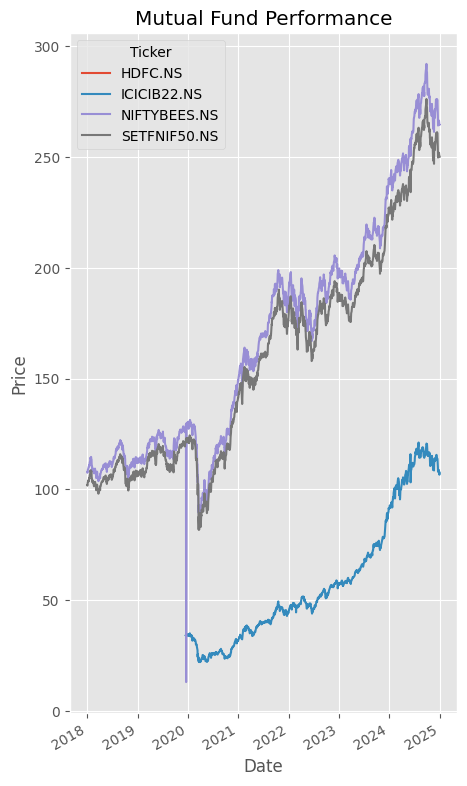

In [11]:
fund_data.plot(figsize=(5,10))
plt.title("Mutual Fund Performance")
plt.ylabel("Price")
plt.xlabel("Date")
plt.show()

In [12]:
daily_return = fund_data.pct_change()
daily_return.head()

/tmp/ipykernel_17014/4231067755.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  daily_return = fund_data.pct_change()


Ticker,HDFC.NS,ICICIB22.NS,NIFTYBEES.NS,SETFNIF50.NS
Date,,,,
2018-01-01,NaN,NaN,NaN,NaN
2018-01-02,NaN,NaN,-0.003274,-0.001985
2018-01-03,NaN,NaN,0.001563,0.006158
2018-01-04,NaN,NaN,0.005082,0.005838
2018-01-05,NaN,NaN,0.005029,0.003276


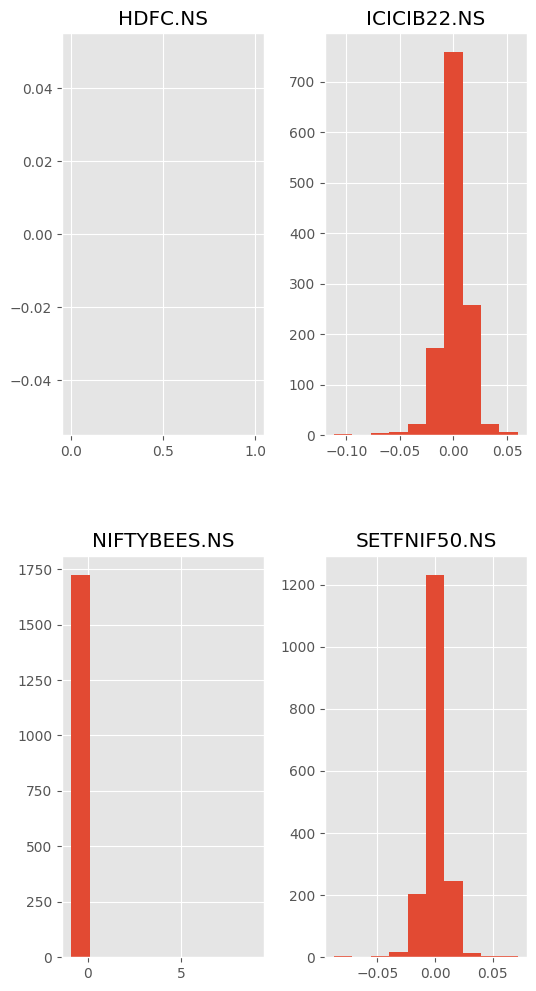

In [13]:
daily_return.hist(figsize=(6,12))
plt.show()

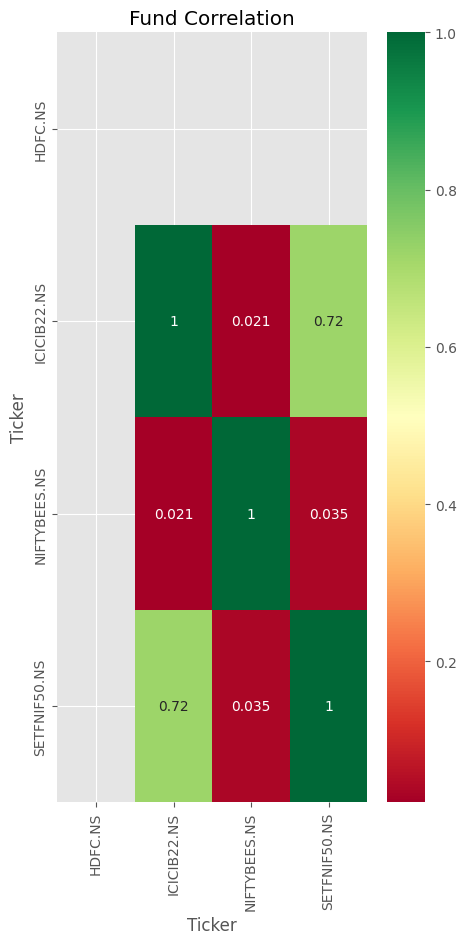

In [15]:
plt.figure(figsize=(5,10))
sns.heatmap(daily_return.corr(), annot=True, cmap='RdYlGn')
plt.title("Fund Correlation")
plt.show()


In [16]:
weights = np.array([0.4,0.3,0.2,0.1])
weights.sum()

np.float64(0.9999999999999999)

In [18]:
annual_returns = daily_return.mean() * 252

portfolio_return = np.sum(
    annual_returns * weights
)

portfolio_return

np.float64(0.3549793522119932)

In [19]:
cov_matrix = daily_return.cov() * 252

portfolio_risk = np.sqrt(
    np.dot(weights.T,
    np.dot(cov_matrix, weights))
)

portfolio_risk

np.float64(nan)

In [20]:
risk_free_rate = 0.05

sharpe_ratio = (
    portfolio_return - risk_free_rate
) / portfolio_risk

sharpe_ratio

np.float64(nan)

In [23]:
negative_returns = daily_return[
    daily_return < 0
]

downside_std = negative_returns.std() * np.sqrt(252)

sortino_ratio = (
    portfolio_return - risk_free_rate
) / downside_std.mean()

sortino_ratio

np.float64(1.0771520635337868)

In [24]:
num_portfolios = 1000

results = []

for i in range(num_portfolios):

    weights = np.random.random(
        len(funds)
    )

    weights /= np.sum(weights)

    returns = np.sum(
        annual_returns * weights
    )

    risk = np.sqrt(
        np.dot(weights.T,
        np.dot(cov_matrix, weights))
    )

    sharpe = (
        returns - risk_free_rate
    ) / risk

    results.append(
        [returns, risk, sharpe]
    )

results_df = pd.DataFrame(
    results,
    columns=[
        'Return',
        'Risk',
        'Sharpe'
    ]
)

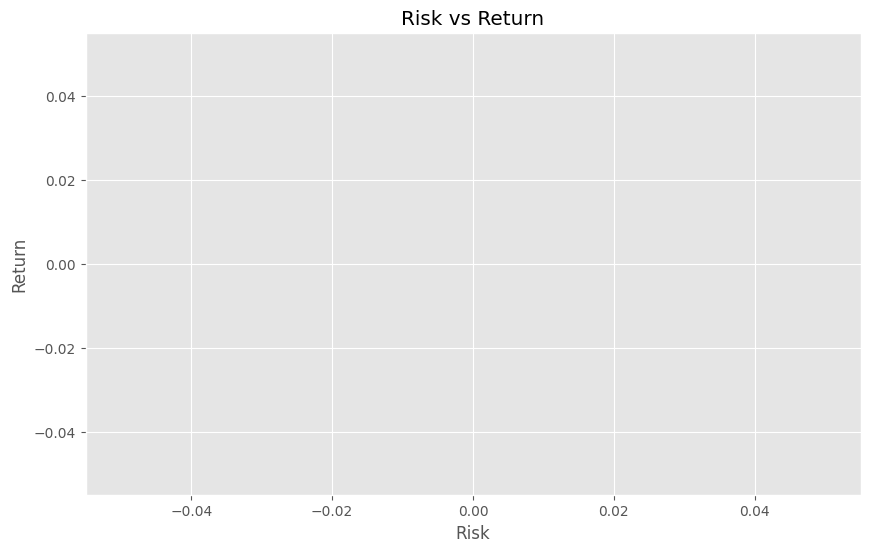

In [25]:
plt.figure(figsize=(10,6))

plt.scatter(
    results_df['Risk'],
    results_df['Return']
)

plt.xlabel("Risk")
plt.ylabel("Return")
plt.title("Risk vs Return")
plt.show()

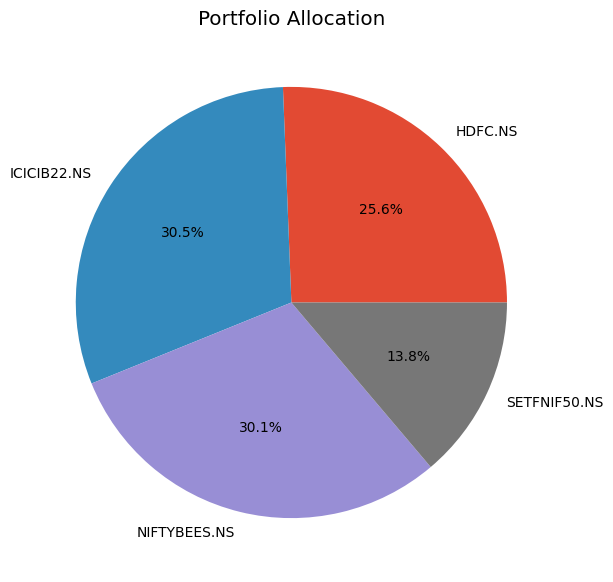

In [26]:
labels = funds

plt.figure(figsize=(7,7))

plt.pie(
    weights,
    labels=labels,
    autopct='%1.1f%%'
)

plt.title(
    "Portfolio Allocation"
)

plt.show()

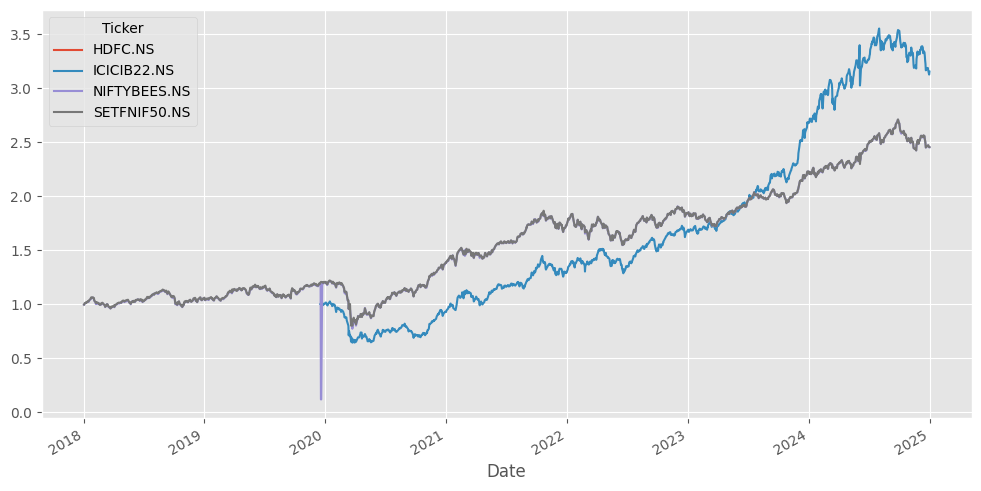

In [28]:
cumulative_return = (
    1 + daily_return
).cumprod()

cumulative_return.plot(
    figsize=(12,6)
)

plt.show()

In [30]:
investment_amount = 100000
years = 10

future_value = (
    investment_amount
    * (1 + portfolio_return)
    ** years
)

future_value

np.float64(2086059.8907200864)

In [31]:
best_portfolio = results_df[
    results_df['Sharpe']
    ==
    results_df['Sharpe'].max()
]

best_portfolio

,Return,Risk,Sharpe


In [32]:
print("Expected Return:",
      portfolio_return)

print("Portfolio Risk:",
      portfolio_risk)

print("Sharpe Ratio:",
      sharpe_ratio)

print("Future Value:",
      future_value)

Expected Return: 0.3549793522119932
Portfolio Risk: nan
Sharpe Ratio: nan
Future Value: 2086059.8907200864
